In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.9 MB/s eta 0:00:00


In [2]:
from Bio import Entrez, SeqIO

# NCBI wants to know who is accessing their data
Entrez.email = "your.email@example.com"

# These are the official database codes for the DNA
cat_codes = {
    "Lion": "NC_008206",
    "Tiger": "NC_010642",
    "Leopard": "NC_010641",
    "Jaguar": "NC_010618",
    "Cheetah": "NC_005212"  # The Cheetah is our "outgroup" for comparison
}

dna_records = []
print("Connecting to NCBI database...")

for cat_name, code in cat_codes.items():
    # Fetch the DNA sequence in FASTA format
    handle = Entrez.efetch(db="nucleotide", id=code, rettype="fasta", retmode="text")
    record = SeqIO.read(handle, "fasta")

    # Rename the record ID to the animal's name
    record.id = cat_name
    record.description = ""
    dna_records.append(record)
    print(f"Successfully downloaded {cat_name} DNA!")

# Save all sequences into one master file
SeqIO.write(dna_records, "big_cats.fasta", "fasta")
print("\nAll done! Saved as 'big_cats.fasta'.")

Connecting to NCBI database...
Successfully downloaded Lion DNA!
Successfully downloaded Tiger DNA!
Successfully downloaded Leopard DNA!
Successfully downloaded Jaguar DNA!
Successfully downloaded Cheetah DNA!

All done! Saved as 'big_cats.fasta'.


In [3]:
for record in SeqIO.parse("big_cats.fasta", "fasta"):
    print(f"{record.id}:")
    print(f"{record.seq[:100]}...\n")

Lion:
CCACTGCAACAGCGCTTCATCCCCCTAGGTAGTTTTGGGGGTTGCGAAGATTTTCATTTATTGCGTTTGACCTGCGTAAATAATCCGCTGGGCATGTTCG...

Tiger:
GGGTTAATGACTAATCAGCCCATGATCACACATAACTGTGGTGTCATGCATTTGGTATTTTTAATTTTTAGGGGGTCGAACTTGCTATGACTCAGCTATG...

Leopard:
GGGTTAGTGACTAATCAGCCCATGATCACACATAACTGTGGTGTCATGCATTTGGTATTTTTAATTTTTAGGGGGTCGAACTTGCTATGACTCAGCTATG...

Jaguar:
ACCGGATGGCCGCGCGATTTTTTTACAGTGGTCCCCTCCATGTTTGCGTTTGTCCAATGGAATGCGCTCCTCAAAGCTTATTTATGGAATGGTCCCCTAT...

Cheetah:
GGATTAATGACTAATCAGCCCATGATCACACATAACTGTGGTGTCATGCATTTGGTATCTTTAATTTTTAGGGGGTCGAACTTGCTATGACTCAGCTATG...



In [4]:
# Install Clustal Omega (runs standard Linux commands in the background)
!apt-get install clustalo -y

# Run the aligner: -i is input, -o is output
!clustalo -i big_cats.fasta -o aligned_cats.fasta --force
print("Alignment complete! Sequences are lined up and saved as 'aligned_cats.fasta'")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libargtable2-0
The following NEW packages will be installed:
  clustalo libargtable2-0
0 upgraded, 2 newly installed, 0 to remove and 2 not upgraded.
Need to get 273 kB of archives.
After this operation, 694 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libargtable2-0 amd64 13-1.1 [14.1 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 clustalo amd64 1.2.4-7 [259 kB]
Fetched 273 kB in 1s (252 kB/s)
Selecting previously unselected package libargtable2-0.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../libargtable2-0_13-1.1_amd64.deb ...
Unpacking libargtable2-0 (13-1.1) ...
Selecting previously unselected package clustalo.
Preparing to unpack .../clustalo_1.2.4-7_amd64.deb ...
Unpacking clustalo (1.2.4-7) ...
Setting up 

Distance Matrix Calculated!


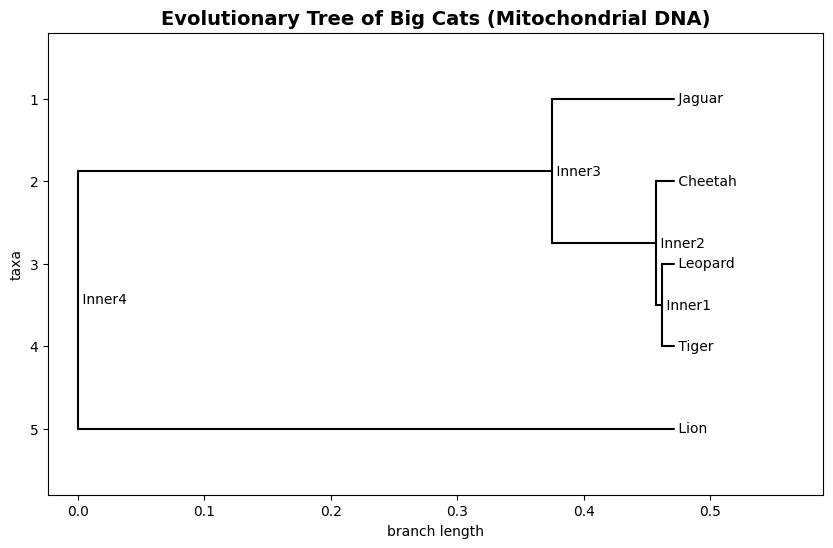

In [8]:
from Bio import AlignIO, Phylo
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
import matplotlib.pyplot as plt

# 1. Load the perfectly aligned DNA
alignment = AlignIO.read("aligned_cats.fasta", "fasta")

# 2. Calculate the genetic distance matrix
# (This counts the percentage of mismatches between sequences)
calculator = DistanceCalculator('identity')
distance_matrix = calculator.get_distance(alignment)
print("Distance Matrix Calculated!")

# 3. Construct the evolutionary tree using the UPGMA algorithm
constructor = DistanceTreeConstructor()
tree = constructor.upgma(distance_matrix)

# 4. Render the tree using Matplotlib
fig = plt.figure(figsize=(10, 6), dpi=100)
axes = fig.add_subplot(1, 1, 1)

# Clean up the graph aesthetics
plt.title("Evolutionary Tree of Big Cats (Mitochondrial DNA)", fontsize=14, fontweight='bold')
plt.xlabel("Genetic Distance (Mutations)")
plt.ylabel("Species")

Phylo.draw(tree, axes=axes, do_show=False)
plt.show()

In [7]:
Phylo.write(tree, "big_cats_tree.nwk", "newick")
print("Newick file ready! Download this one.")

Newick file ready! Download this one.
